<a href="https://colab.research.google.com/github/ashwithareddykatta-code/sentiment-analysis-projects/blob/main/task_3_bag_of_word_rep_from_user_text_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Saving sample_bow_text.txt to sample_bow_text (1).txt
Original Text:

Artificial Intelligence (AI) is transforming many industries. AI systems
can analyze data, recognize patterns, and assist humans in decision
making. Machine learning is a subset of AI that allows computers to
learn from data. Natural language processing enables machines to
understand human language. Computer vision allows machines to interpret
visual information from images and videos.

AI is widely used in healthcare. Doctors use AI systems to help diagnose
diseases earlier. In finance, AI help

Number of Sentences (Documents): 13

Sample Sentences:
['Artificial Intelligence (AI) is transforming many industries.', 'AI systems\ncan analyze data, recognize patterns, and assist humans in decision\nmaking.', 'Machine learning is a subset of AI that allows computers to\nlearn from data.']

Vocabulary and Word Counts:

          Word  Count
0           ai     10
58     systems      3
1       allows      2
25        help  

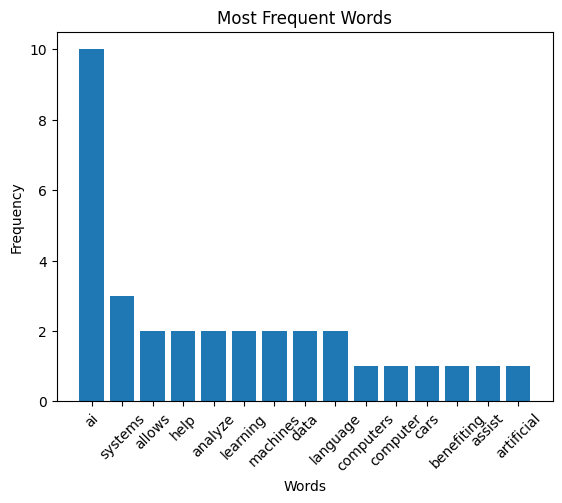

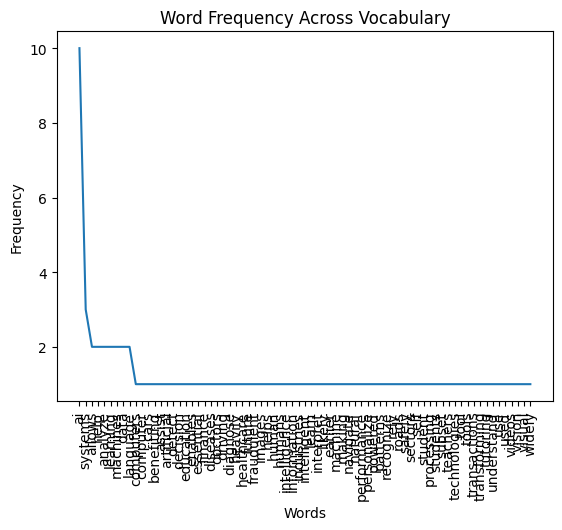

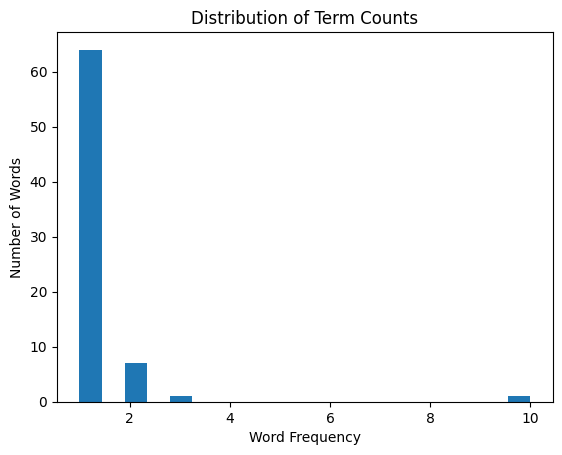

In [ ]:
# Install required libraries (usually already installed in Colab)
!pip install scikit-learn nltk

import nltk
nltk.download('punkt_tab')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import sent_tokenize

from google.colab import files

# Step 1: Upload text file
uploaded = files.upload()

# Get file name
file_name = list(uploaded.keys())[0]

# Read text
with open(file_name, 'r', encoding='utf-8') as f:
    text = f.read()

print("Original Text:\n")
print(text[:500])

# Step 2: Split text into sentences (documents)
documents = sent_tokenize(text)

print("\nNumber of Sentences (Documents):", len(documents))
print("\nSample Sentences:")
print(documents[:3])

# Step 3: Apply Bag of Words using CountVectorizer
vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(documents)

# Vocabulary
vocab = vectorizer.get_feature_names_out()

# Word counts
word_counts = np.array(X.sum(axis=0)).flatten()

# Create dataframe
df = pd.DataFrame({
    "Word": vocab,
    "Count": word_counts
})

# Sort by frequency
df = df.sort_values(by="Count", ascending=False)

print("\nVocabulary and Word Counts:\n")
print(df.head(20))

# -------- Visualization 1: Bar Plot (Most Frequent Words) --------
top_n = 15
top_words = df.head(top_n)

plt.figure()
plt.bar(top_words["Word"], top_words["Count"])
plt.xticks(rotation=45)
plt.title("Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

# -------- Visualization 2: Line Plot (Frequency across vocabulary) --------
plt.figure()
plt.plot(df["Word"], df["Count"])
plt.xticks(rotation=90)
plt.title("Word Frequency Across Vocabulary")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

# -------- Visualization 3: Histogram (Distribution of Term Counts) --------
plt.figure()
plt.hist(df["Count"], bins=20)
plt.title("Distribution of Term Counts")
plt.xlabel("Word Frequency")
plt.ylabel("Number of Words")
plt.show()